# Task 1:

#### done this task using linear regression

In [56]:
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [52]:
df = pd.read_csv("house-prices.csv")
print(df.shape)
df.head()

(128, 8)


,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


In [5]:
df.isnull().sum()

Home            0
Price           0
SqFt            0
Bedrooms        0
Bathrooms       0
Offers          0
Brick           0
Neighborhood    0
dtype: int64

In [7]:
le = LabelEncoder()
df['Brick'] = le.fit_transform(df['Brick'])

df = pd.get_dummies(df, columns=['Neighborhood'], drop_first = True)
df.head()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood_North,Neighborhood_West
0,1,114300,1790,2,2,2,0,False,False
1,2,114200,2030,4,2,3,0,False,False
2,3,114800,1740,3,2,1,0,False,False
3,4,94700,1980,3,2,3,0,False,False
4,5,119800,2130,3,3,3,0,False,False


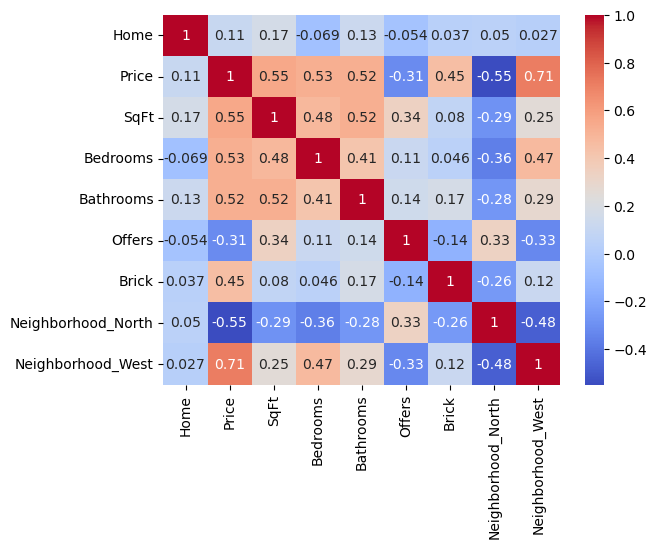

In [14]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [16]:
x = df.drop('Price', axis=1)
y = df['Price']

#X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
kfold = KFold(n_splits=5, shuffle=True, random_states=42)
accuracyScores = []

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluation Metrics:")
print(f"MAE: {mae}")
print(f"MSE: {mse}\nR^2 Score: {r2}")
print("Model score (R^2): ", model.score(X_test, y_test))
print('\n')

#predict for new house
new_house = pd.DataFrame([{
    'Home': 1800,                  
    'SqFt': 190000,            
    'Bedrooms': 7,        
    'Bathrooms': 4,       
    'Offers': 5,         
    'Brick': 0,           
    'Neighborhood_North':0,
    'Neighborhood_West': 1
}])

predicted_price = model.predict(new_house)
print(f"Predicted price for the new house: {predicted_price[0]}")

Evaluation Metrics:
MAE: 8858.885607471871
MSE: 114251135.71732599
R^2 Score: 0.8061565137761021
Model score (R^2):  0.8061565137761021


Predicted price for the new house: 11435447.852954207


# Task 2:

#### done this using decision tree classifier

In [50]:
df2 = pd.read_csv('enron_spam_data.csv')
print(df2.shape)
df2.head()

(33716, 5)


,Message ID,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14


In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# combining subject and message
df2['text'] = df2['Subject'].fillna('') + " " + df2['Message'].fillna('')

#encoding labels
labelencoder = LabelEncoder()
df2['label'] = labelencoder.fit_transform(df2['Spam/Ham'])

#text vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
x = vectorizer.fit_transform(df2['text'])
y = df2['label']

df2.head()

,Message ID,Subject,Message,Spam/Ham,Date,text,label
0,0,christmas tree farm pictures,NaN,ham,1999-12-10,christmas tree farm pictures,0
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13,"vastar resources , inc . gary , production fro...",0
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14,calpine daily gas nomination - calpine daily g...,0
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14,re : issue fyi - see note below - already done...,0
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,meter 7268 nov allocation fyi .\n- - - - - - -...,0


In [68]:
#splitting
#X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
from sklearn.model_selection import cross_val_predict

#training dt
dt = DecisionTreeClassifier()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(dt, x, y, cv=kfold, scoring='accuracy')
print("K-Fold Accuracy Scores:", scores)
print("Mean Accuracy:", scores.mean())

# Cross-validated predictions
predictions = cross_val_predict(dt, x, y, cv=kfold)
test_accuracy = accuracy_score(y, predictions)
print(f"Test Accuracy (Cross-Validation): {test_accuracy}")

# Optional: Fit on full data (if deploying or further analyzing)
dt.fit(x, y)
train_accuracy = dt.score(x, y)
print(f"Training Accuracy (on full data): {train_accuracy}")

K-Fold Accuracy Scores: [0.95907473 0.96247961 0.95877206 0.96247961 0.96114489]
Mean Accuracy: 0.9607901801947769
Test Accuracy (Cross-Validation): 0.9615019575275834
Training Accuracy (on full data): 0.9997923834381303


# Task 3:

#### doing this task using svc

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report

You work for a retail business and your task is to classify customers into two categories:
high-value and low-value customers. The classification is based on customer features
such as total spending in the last 6 months, age, number of visits, and purchase
frequency. You have a dataset with customer information, including spending habits,
frequency of visits, and demographics. The goal is to classify customers into high-value
(1) and low-value (0) categories.
● Clean the dataset and handle any missing or outlier values. Perform feature
scaling if necessary.
● Divide the dataset into a training set and a testing set.
● Find a separating hyperplane for classification.
● Find rules that classify customers based on their features.
● Evaluate the performance of the model.

In [ ]:

# For reproducibility
np.random.seed(727)
num_samples = 1000
records = {
    'spending': np.random.lognormal(mean=6, sigma=1, size=num_samples),
    'age': np.random.randint(18, 80, size=num_samples),
    'visits': np.random.randint(1, 50, size=num_samples),
    'frequency': np.random.uniform(0.5, 10, size=num_samples),
    'label': np.zeros(num_samples, dtype=int)
}

# Scoring mechanism and threshold for classification
weights = {'spending': 0.0005, 'visits': 0.1, 'frequency': 0.2}
score_values = np.array([
    records['spending'][i] * weights['spending'] +
    records['visits'][i] * weights['visits'] +
    records['frequency'][i] * weights['frequency']
    for i in range(num_samples)
])
cutoff = np.percentile(score_values, 70)
records['label'] = (score_values > cutoff).astype(int)

df = pd.DataFrame(records)

# Simulate missing values
df.loc[np.random.choice(df.index, 50), 'spending'] = np.nan
df.loc[np.random.choice(df.index, 30), 'frequency'] = np.nan

df['spending'].fillna(df['spending'].median(), inplace=True)
df['frequency'].fillna(df['frequency'].median(), inplace=True)

# Outlier control
def trim_extremes(series):
    lower = series.quantile(0.25)
    upper = series.quantile(0.75)
    spread = upper - lower
    min_val = lower - 1.5 * spread
    max_val = upper + 1.5 * spread
    return series.clip(min_val, max_val)

for field in ['spending', 'visits', 'frequency']:
    df[field] = trim_extremes(df[field])

# Class ratio output
print("Label Breakdown:")
print(df['label'].value_counts(normalize=True))

# Feature and label separation
features = ['spending', 'age', 'visits', 'frequency']
X = df[features]
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVC model with balanced class weights
svc_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svc_model.fit(X_train_scaled, y_train)

# Report generation
report = classification_report(
    y_test, svc_model.predict(X_test_scaled),
    target_names=['Low-Value', 'High-Value'],
    output_dict=True
)

# Plotting classification performance
sns.heatmap(pd.DataFrame(report).T, cmap='crest', annot=True, fmt='.2f')

# Prediction for a hypothetical customer
sample = pd.DataFrame([{
    'spending': 1000,
    'age': 35,
    'visits': 20,
    'frequency': 5
}])
sample_scaled = scaler.transform(sample)
predicted_class = svc_model.predict(sample_scaled)[0]
print("Customer Type:", "High-Value" if predicted_class == 1 else "Low-Value")
